# CLUSTERING

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import re


In [11]:
raw_df = pd.read_csv('/Users/ansonliu/Github/movie_behavioural_disagreements/data/model/model_input_df.csv')

In [12]:
cut_df = raw_df[['budget', 'genres', 'production_companies', 'production_countries', 'keywords', 'overview', 'Tomatometer', 'Popcornmeter']].copy()

In [13]:
cut_df.head()

,budget,genres,production_companies,production_countries,keywords,overview,Tomatometer,Popcornmeter
0,160000000,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","rescue, mission, dream, airplane, paris, franc...","Cobb, a skilled thief who commits corporate es...",87,91
1,165000000,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America","rescue, future, spacecraft, race against time,...",The adventures of a group of explorers who mak...,73,87
2,185000000,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","joker, sadism, chaos, secret identity, crime f...",Batman raises the stakes in his war on crime. ...,94,94
3,237000000,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","future, society, culture clash, space travel, ...","In the 22nd century, a paraplegic Marine is di...",81,82
4,58000000,"Action, Adventure, Comedy","20th Century Fox, The Donners' Company, Genre ...",United States of America,"superhero, anti hero, mercenary, based on comi...",The origin story of former Special Forces oper...,85,90


In [15]:
cut_df['scores_abs_diff'] = (cut_df['Tomatometer'] - cut_df['Popcornmeter']).abs()

=== Feature Engineering for Clustering ===

Score difference stats:
  Mean diff: -7.33
  Mean absolute diff: 16.28
  Critics higher: 1173 movies
  Audiences higher: 1837 movies

Creating genre features...


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ansonliu/nltk_data...



Created 19 genre features
High sentiment movies: 2419 (78.5%)

Total features for clustering: 29

=== HDBSCAN Clustering ===

HDBSCAN Results:
  Number of clusters found: 26
  Noise points (cluster -1): 1643 (53.3%)
  Clustered points: 1439 (46.7%)


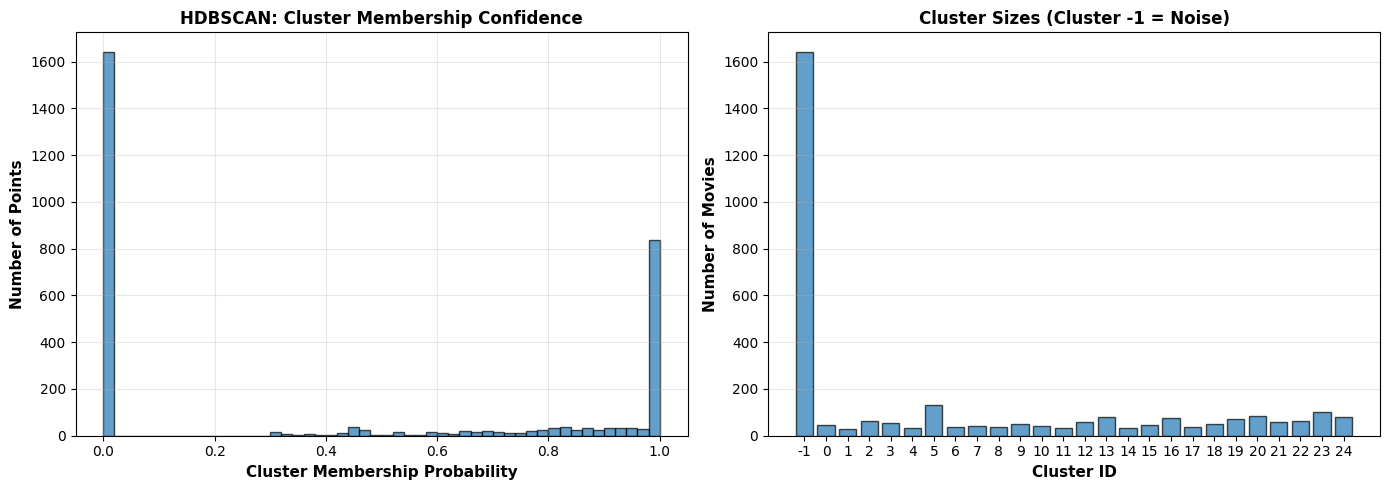


=== Cluster Analysis ===

--- Noise (1643 movies, 53.3%) ---
  Score Difference (Critics - Audience):
    Mean: -6.78
    Median: -5.00
  Average Score: 59.72
  Budget (mean): $49.3M
  Top Studio: 68.4%
  High Sentiment: 81.4%
  Overview Sentiment: -0.087

--- Cluster 0 (44 movies, 1.4%) ---
  Score Difference (Critics - Audience):
    Mean: -1.07
    Median: 0.00
  Average Score: 50.06
  Budget (mean): $17.3M
  Top Studio: 90.9%
  High Sentiment: 0.0%
  Overview Sentiment: -0.492
  Top genres:
    - Mystery: 40.9%
    - Horror: 100.0%

--- Cluster 1 (30 movies, 1.0%) ---
  Score Difference (Critics - Audience):
    Mean: -4.73
    Median: -3.50
  Average Score: 64.03
  Budget (mean): $151.5M
  Top Studio: 100.0%
  High Sentiment: 0.0%
  Overview Sentiment: 0.059
  Top genres:
    - Adventure: 100.0%
    - Fantasy: 100.0%
    - Family: 63.3%

--- Cluster 2 (65 movies, 2.1%) ---
  Score Difference (Critics - Audience):
    Mean: -2.37
    Median: -2.00
  Average Score: 66.82
  Budget (

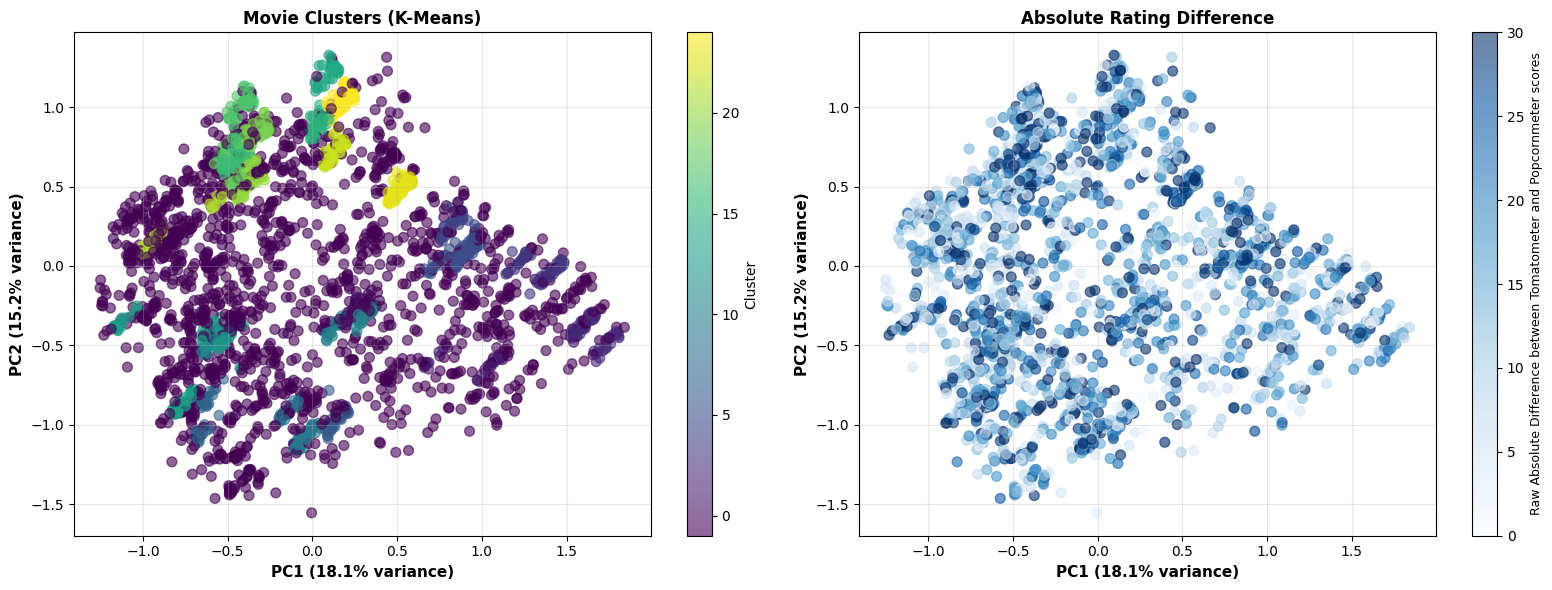

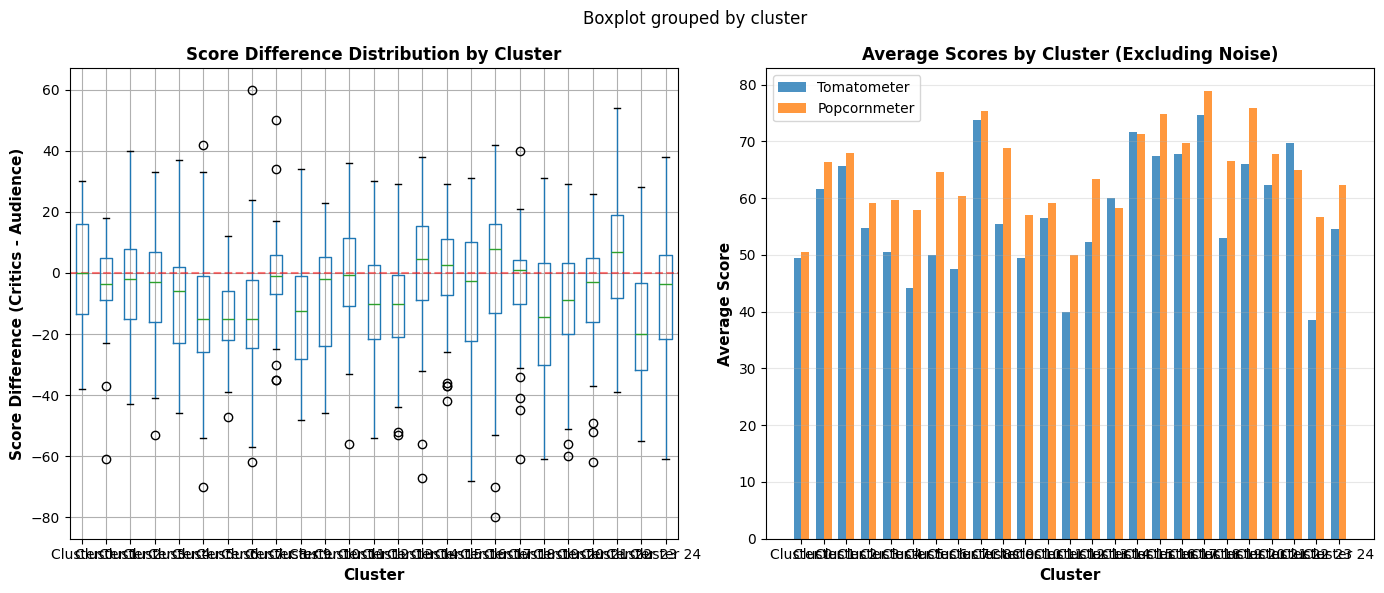


=== Cluster Interpretation ===
Look for patterns like:
- Do high-budget blockbusters have different critic/audience gaps?
- Do high-sentiment (emotional) movies show larger discrepancies?
- Do certain genre combinations cluster together with similar gaps?
- Does overview sentiment predict which group will like it more?


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import re

# Create a copy
df = cut_df.copy()

# Remove rows with missing scores
df = df.dropna(subset=['Tomatometer', 'Popcornmeter'])

print("=== Feature Engineering for Clustering ===")

# 1. Calculate score difference (our key metric)
df['score_diff'] = df['Tomatometer'] - df['Popcornmeter']
df['score_abs_diff'] = abs(df['score_diff'])
df['avg_score'] = (df['Tomatometer'] + df['Popcornmeter']) / 2
df['abs_score_diff'] = abs(df['score_diff'])

print(f"\nScore difference stats:")
print(f"  Mean diff: {df['score_diff'].mean():.2f}")
print(f"  Mean absolute diff: {df['score_abs_diff'].mean():.2f}")
print(f"  Critics higher: {(df['score_diff'] > 0).sum()} movies")
print(f"  Audiences higher: {(df['score_diff'] < 0).sum()} movies")

# 2. Budget features
df['log_budget'] = np.log1p(df['budget'].fillna(0))

# 3. Production countries count
df['num_countries'] = df['production_countries'].str.split(',').str.len()
df['num_countries'] = df['num_countries'].fillna(0)

# 4. Individual genre dummies
print("\nCreating genre features...")
genres_exploded = df['genres'].str.split(', ').explode()
genres_exploded = genres_exploded.str.strip()
unique_genres = genres_exploded[genres_exploded.notna()].unique()

df['genres'] = df['genres'].fillna('')

for genre in unique_genres:
    genre_safe = genre.replace(' ', '_').replace('/', '_')
    pattern = r'\b' + re.escape(genre) + r'\b'
    df[f'genre_{genre_safe}'] = (
        df['genres'].str.contains(pattern, case=False, regex=True).astype(int)
    )

genre_columns = [f'genre_{genre.replace(" ", "_").replace("/", "_")}' for genre in unique_genres]

# 5. High sentiment genres (emotional content)
high_sentiment_genres = ['Romance', 'Drama', 'War', 'Action', 'Thriller', 'Musical']
df['high_sentiment'] = 0
for genre in high_sentiment_genres:
    pattern = r'\b' + re.escape(genre) + r'\b'
    df['high_sentiment'] |= df['genres'].str.contains(pattern, case=False, regex=True).astype(int)

# 6. Top studio indicator
top_n_companies = 30
companies_exploded = df['production_companies'].str.split(', ').explode()
top_companies = companies_exploded.value_counts().head(top_n_companies).index
df['production_companies_list'] = df['production_companies'].str.split(', ')
df['is_top_studio'] = df['production_companies_list'].apply(
    lambda x: 1 if isinstance(x, list) and any(company in top_companies for company in x) else 0
)

# 7. Text features (keywords and overview)
df['num_keywords'] = df['keywords'].str.split(',').str.len()
df['num_keywords'] = df['num_keywords'].fillna(0)

df['overview_length'] = df['overview'].str.len().fillna(0)
df['overview_word_count'] = df['overview'].str.split().str.len().fillna(0)

# # Sentiment analysis
# from textblob import TextBlob
# df['overview_sentiment'] = df['overview'].apply(
#     lambda x: TextBlob(str(x)).sentiment.polarity if pd.notna(x) else 0
# )
# df['overview_subjectivity'] = df['overview'].apply(
#     lambda x: TextBlob(str(x)).sentiment.subjectivity if pd.notna(x) else 0
# )

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download required data
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

# VADER gives compound score (-1 to 1) that captures intensity better
df['overview_sentiment'] = df['overview'].apply(
    lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0
)

# Get negative, neutral, positive intensities
df['overview_negative'] = df['overview'].apply(
    lambda x: sia.polarity_scores(str(x))['neg'] if pd.notna(x) else 0
)
df['overview_positive'] = df['overview'].apply(
    lambda x: sia.polarity_scores(str(x))['pos'] if pd.notna(x) else 0
)

# Arousal proxy: combined emotional intensity
df['overview_arousal'] = df['overview_negative'] + df['overview_positive']

print(f"\nCreated {len(genre_columns)} genre features")
print(f"High sentiment movies: {df['high_sentiment'].sum()} ({df['high_sentiment'].mean()*100:.1f}%)")

# Prepare features for clustering
feature_columns = [
    'log_budget', 'num_countries', 'is_top_studio',
    'num_keywords', 'overview_length', 'overview_word_count',
    'overview_sentiment', 'overview_arousal', 'high_sentiment',
    'avg_score'  # Include average score as context
] + genre_columns

X = df[feature_columns].fillna(0)

# Standardize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nTotal features for clustering: {X_scaled.shape[1]}")

# Use HDBSCAN for density-based clustering
print("\n=== HDBSCAN Clustering ===")
import hdbscan

# HDBSCAN with different parameters
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,  # Minimum size for a cluster
    min_samples=10,       # More conservative - fewer noise points
    metric='euclidean',
    cluster_selection_method='eom'  # Excess of Mass
)

df['cluster'] = clusterer.fit_predict(X_scaled)

# Get clustering metrics
n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'] else 0)
n_noise = list(df['cluster']).count(-1)

print(f"\nHDBSCAN Results:")
print(f"  Number of clusters found: {n_clusters}")
print(f"  Noise points (cluster -1): {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"  Clustered points: {len(df) - n_noise} ({(len(df)-n_noise)/len(df)*100:.1f}%)")

# Visualize cluster probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(clusterer.probabilities_, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Cluster Membership Probability', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Points', fontsize=11, fontweight='bold')
axes[0].set_title('HDBSCAN: Cluster Membership Confidence', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cluster sizes
cluster_sizes = df['cluster'].value_counts().sort_index()
axes[1].bar(range(len(cluster_sizes)), cluster_sizes.values, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Movies', fontsize=11, fontweight='bold')
axes[1].set_title('Cluster Sizes (Cluster -1 = Noise)', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(len(cluster_sizes)))
axes[1].set_xticklabels([f'{idx}' for idx in cluster_sizes.index])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Analyze clusters
print("\n=== Cluster Analysis ===")
for i in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == i]
    cluster_name = "Noise" if i == -1 else f"Cluster {i}"
    print(f"\n--- {cluster_name} ({len(cluster_data)} movies, {len(cluster_data)/len(df)*100:.1f}%) ---")
    print(f"  Score Difference (Critics - Audience):")
    print(f"    Mean: {cluster_data['score_diff'].mean():.2f}")
    print(f"    Median: {cluster_data['score_diff'].median():.2f}")
    print(f"  Average Score: {cluster_data['avg_score'].mean():.2f}")
    print(f"  Budget (mean): ${cluster_data['budget'].mean()/1e6:.1f}M")
    print(f"  Top Studio: {cluster_data['is_top_studio'].mean()*100:.1f}%")
    print(f"  High Sentiment: {cluster_data['high_sentiment'].mean()*100:.1f}%")
    print(f"  Overview Sentiment: {cluster_data['overview_sentiment'].mean():.3f}")
    
    if i != -1:  # Don't show detailed genre breakdown for noise
        print(f"  Top genres:")
        for col in genre_columns:
            if cluster_data[col].sum() > 0:
                pct = cluster_data[col].mean() * 100
                if pct > 30:  # Only show genres that appear in >30% of cluster
                    genre_name = col.replace('genre_', '').replace('_', ' ')
                    print(f"    - {genre_name}: {pct:.1f}%")

# Visualize clusters in 2D using PCA
print("\n=== PCA Visualization ===")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters colored by cluster assignment
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], 
                         cmap='viridis', alpha=0.6, s=50)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', 
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', 
                   fontsize=11, fontweight='bold')
axes[0].set_title('Movie Clusters (K-Means)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].grid(True, alpha=0.3)

# Plot 2: Coloured by score difference
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['abs_score_diff'], 
                          cmap='Blues', alpha=0.6, s=50, vmin=0, vmax=30)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', 
                   fontsize=11, fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', 
                   fontsize=11, fontweight='bold')
axes[1].set_title('Absolute Rating Difference', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter2, ax=axes[1], label='Score Diff')
cbar.set_label('Raw Absolute Difference between Tomatometer and Popcornmeter scores', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots showing score differences by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Only include actual clusters (not noise)
df_clustered = df[df['cluster'] != -1]
n_real_clusters = len(df_clustered['cluster'].unique())

df_clustered.boxplot(column='score_diff', by='cluster', ax=axes[0])
axes[0].set_xlabel('Cluster', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Score Difference (Critics - Audience)', fontsize=11, fontweight='bold')
axes[0].set_title('Score Difference Distribution by Cluster', fontsize=12, fontweight='bold')
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.sca(axes[0])
plt.xticks(range(1, n_real_clusters + 1), [f'Cluster {i}' for i in sorted(df_clustered['cluster'].unique())])

# Average scores by cluster
cluster_means = df_clustered.groupby('cluster')[['Tomatometer', 'Popcornmeter']].mean()
x = np.arange(len(cluster_means))
width = 0.35

axes[1].bar(x - width/2, cluster_means['Tomatometer'], width, label='Tomatometer', alpha=0.8)
axes[1].bar(x + width/2, cluster_means['Popcornmeter'], width, label='Popcornmeter', alpha=0.8)
axes[1].set_xlabel('Cluster', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Average Score', fontsize=11, fontweight='bold')
axes[1].set_title('Average Scores by Cluster (Excluding Noise)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {i}' for i in sorted(df_clustered['cluster'].unique())])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n=== Cluster Interpretation ===")
print("Look for patterns like:")
print("- Do high-budget blockbusters have different critic/audience gaps?")
print("- Do high-sentiment (emotional) movies show larger discrepancies?")
print("- Do certain genre combinations cluster together with similar gaps?")
print("- Does overview sentiment predict which group will like it more?")